<div style="background-color: #e8f4f8; border-left: 6px solid #3498db; padding: 20px; margin: 15px 0; border-radius: 4px;"><h2 style="margin-top: 0; color: #2c3e50; font-size: 22px;">One-Class SVM (OCSVM)</h2><div style="font-size: 16px; line-height: 1.6; color: #2c3e50;"><p><b>How it works:</b> the model learns the shape of the normal data and draws a boundary around it. Anything that falls outside the boundary is flagged as an anomaly. The RBF kernel allows the boundary to be non-linear, which is needed for complex data.</p><p><b>Result on this dataset:</b></p><ul><li>F1 = 0.58 - catches the most anomalies overall (high recall)</li><li>Produces more false alarms than other ML models</li><li>A classical anomaly detection method, included for comparison</li></ul></div></div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

## Load data and split

**Note:** One-Class SVM with RBF kernel is very sensitive to feature scale, so we must standardize the data first.

In [2]:
data = pd.read_csv('../data/labeled.csv', parse_dates=['timestamp'])
split_point = int(len(data) * 0.8)
train_data = data.iloc[:split_point]
test_data = data.iloc[split_point:]

feature_columns = ['memory_pct', 'roll_mean_1h', 'roll_std_1h', 'roll_mean_24h',
                   'diff_1', 'diff_6', 'hour', 'minute', 'time_of_day', 'day_of_week', 'is_weekend']

X_train = train_data[feature_columns].values
X_test = test_data[feature_columns].values
y_test = test_data['label'].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Anomalies in test:', y_test.sum())

Anomalies in test: 98


## Train One-Class SVM

**Hyperparameters:**
- `kernel='rbf'` — radial basis function, allows non-linear boundaries
- `nu=0.005` — upper bound on the fraction of training errors (similar to contamination)
- `gamma='scale'` — automatic kernel coefficient based on feature variance

In [3]:
ocsvm_model = OneClassSVM(kernel='rbf', nu=0.005, gamma='scale')
ocsvm_model.fit(X_train_scaled)

ocsvm_predictions = (ocsvm_model.predict(X_test_scaled) == -1).astype(int)
ocsvm_scores = -ocsvm_model.score_samples(X_test_scaled)

print('Points flagged as anomaly:', ocsvm_predictions.sum())

Points flagged as anomaly: 137


## Visualizing detections

- 🟢 **Green** — True Positive
- 🔴 **Red X** — False Negative (missed)
- 🟠 **Orange triangle** — False Positive (false alarm)

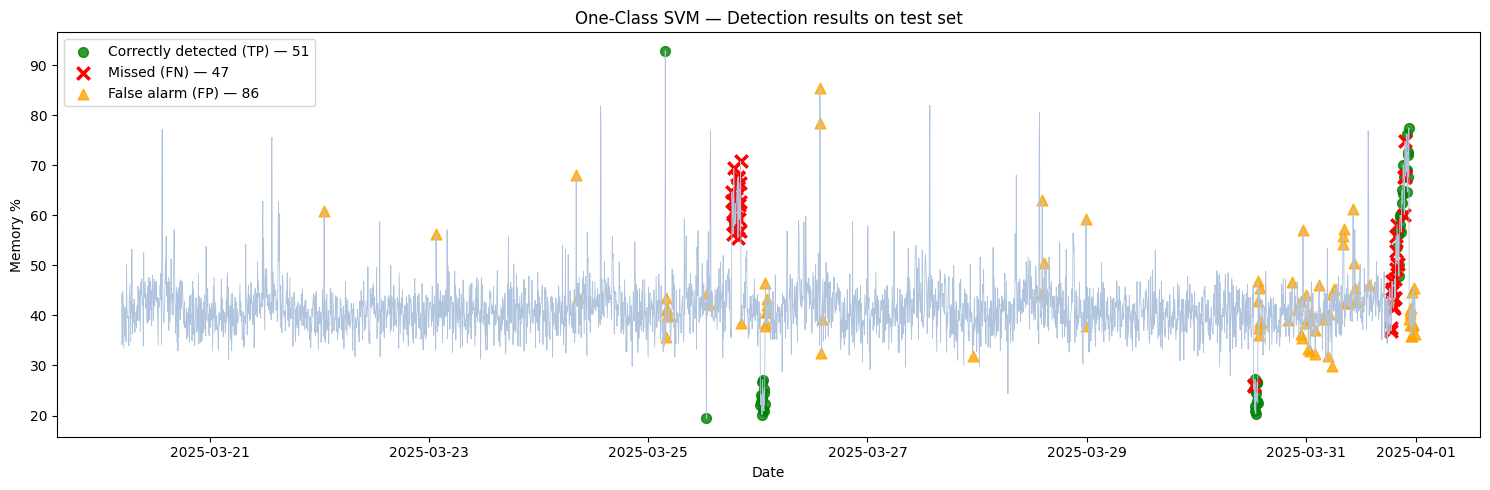

In [4]:
timestamps = test_data['timestamp'].values
memory = test_data['memory_pct'].values

true_positive_mask = (ocsvm_predictions == 1) & (y_test == 1)
false_negative_mask = (ocsvm_predictions == 0) & (y_test == 1)
false_positive_mask = (ocsvm_predictions == 1) & (y_test == 0)

plt.figure(figsize=(15, 5))
plt.plot(timestamps, memory, color='lightsteelblue', linewidth=0.6)
plt.scatter(timestamps[true_positive_mask], memory[true_positive_mask],
            color='green', s=50, alpha=0.8, label=f'Correctly detected (TP) — {true_positive_mask.sum()}')
plt.scatter(timestamps[false_negative_mask], memory[false_negative_mask],
            color='red', marker='x', s=80, linewidths=2.5, label=f'Missed (FN) — {false_negative_mask.sum()}')
plt.scatter(timestamps[false_positive_mask], memory[false_positive_mask],
            color='orange', marker='^', s=60, alpha=0.8, label=f'False alarm (FP) — {false_positive_mask.sum()}')
plt.xlabel('Date')
plt.ylabel('Memory %')
plt.title('One-Class SVM — Detection results on test set')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Confusion matrix

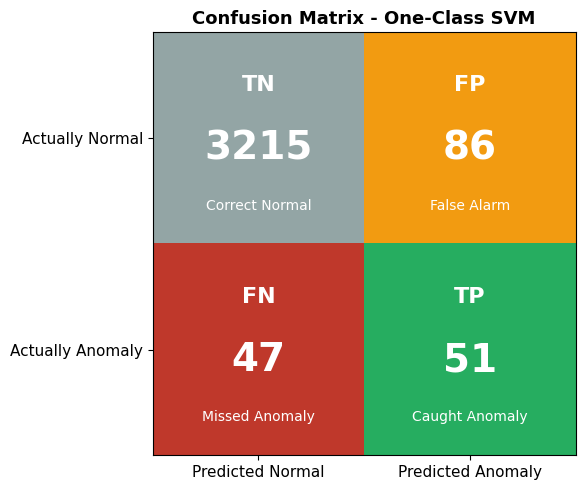

In [5]:
def pretty_cm(cm, title='Confusion Matrix'):
    fig, ax = plt.subplots(figsize=(7, 5))
    # 4 distinct colors - one per outcome category
    rgb = np.zeros((2, 2, 3))
    rgb[0, 0] = [0.58, 0.65, 0.65]  # TN: gray (correct but routine)
    rgb[0, 1] = [0.95, 0.61, 0.07]  # FP: orange (false alarm)
    rgb[1, 0] = [0.75, 0.22, 0.17]  # FN: dark red (MISSED, worst)
    rgb[1, 1] = [0.15, 0.68, 0.38]  # TP: bright green (caught it, best)
    ax.imshow(rgb)
    labels = [['TN', 'FP'], ['FN', 'TP']]
    descriptions = [['Correct Normal', 'False Alarm'], ['Missed Anomaly', 'Caught Anomaly']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i - 0.25, labels[i][j], ha='center', va='center',
                    fontsize=16, fontweight='bold', color='white')
            ax.text(j, i + 0.05, str(cm[i, j]), ha='center', va='center',
                    fontsize=28, fontweight='bold', color='white')
            ax.text(j, i + 0.32, descriptions[i][j], ha='center', va='center',
                    fontsize=10, color='white')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted Normal', 'Predicted Anomaly'], fontsize=11)
    ax.set_yticklabels(['Actually Normal', 'Actually Anomaly'], fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

cm = confusion_matrix(y_test, ocsvm_predictions)
pretty_cm(cm, title='Confusion Matrix - One-Class SVM')

## Evaluation

In [6]:
print(classification_report(y_test, ocsvm_predictions, target_names=['Normal','Anomaly'], zero_division=0))
print('ROC-AUC:', round(roc_auc_score(y_test, ocsvm_scores), 4))

              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98      3301
     Anomaly       0.37      0.52      0.43        98

    accuracy                           0.96      3399
   macro avg       0.68      0.75      0.71      3399
weighted avg       0.97      0.96      0.96      3399

ROC-AUC: 0.9057


<div style="background-color: #fdf6e3; border-left: 6px solid #f39c12; padding: 20px; margin: 15px 0; border-radius: 4px;"><h3 style="margin-top: 0; color: #b9770e; font-size: 20px;">Interpretation</h3><div style="font-size: 16px; line-height: 1.6; color: #5d4e1d;"><p>OCSVM catches the <b>most anomalies</b> (highest recall) among unsupervised models, but at the cost of many false alarms (lower precision).</p><p>This trade-off is typical for boundary-based methods: they cast a wide net.</p><p>Useful for <b>academic comparison</b> - a classical method well-cited in the literature - but not the best practical choice on its own due to the false alarm rate.</p></div></div>

<div style="background-color: #e8f8e8; border-left: 6px solid #27ae60; padding: 20px; margin: 15px 0; border-radius: 4px;"><h3 style="margin-top: 0; color: #1e8449; font-size: 20px;">Summary - Model Performance</h3><div style="font-size: 16px; line-height: 1.6; color: #1e8449;"><p><b>One-Class SVM:</b></p><ul><li><b>F1 ~ 0.58</b> - moderate balanced score</li><li><b>Recall ~ 78%</b> - catches the most anomalies (highest of unsupervised models)</li><li><b>Precision ~ 47%</b> - many false alarms (lowest of ML models)</li></ul><p><b>Strengths:</b> Highest recall - rarely misses an anomaly. Classical, well-cited method.</p><p><b>Weaknesses:</b> Casts a wide net - many false alarms. Sensitive to feature scaling.</p><p><b>Takeaway:</b> Useful as a comparison method and demonstrates the boundary-based approach. Not the best practical choice alone due to false alarm rate, but contributes meaningfully when combined in an ensemble.</p></div></div>